In [60]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

# Load and prepare data
d = pd.read_csv('../data/clean_house_data.csv')
d = d.drop('Id', axis=1)
d.head()


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [62]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load data
d = pd.read_csv('../data/clean_house_data.csv')

# Encode categorical variables
le = LabelEncoder()
d['Location'] = le.fit_transform(d['Location'])
d['Condition'] = le.fit_transform(d['Condition'])
d['Garage'] = le.fit_transform(d['Garage'])

# Scale numerical features
scaler = StandardScaler()
numerical_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']
d[numerical_cols] = scaler.fit_transform(d[numerical_cols])

# Find optimal number of clusters
silhouette_scores = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(d)
    score = silhouette_score(d, kmeans.labels_)
    silhouette_scores.append(score)

optimal_k = K[np.argmax(silhouette_scores)]

# Perform clustering with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
d['Cluster'] = kmeans.fit_predict(d)

# Print cluster characteristics
print(f"\nOptimal number of clusters: {optimal_k}")
print("\nCluster Characteristics:")
print(d.groupby('Cluster').mean())


Optimal number of clusters: 2

Cluster Characteristics:
                  Id      Area  Bedrooms  Bathrooms    Floors  YearBuilt  \
Cluster                                                                    
0         500.268053  0.014245  0.007038   0.015879 -0.002497  -0.031052   
1        1506.230248 -0.014696 -0.007261  -0.016381  0.002576   0.032034   

         Location  Condition    Garage     Price  
Cluster                                           
0        1.464989   1.442013  0.481400  0.016245  
1        1.436795   1.510158  0.480813 -0.016758  


In [69]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Prepare data
d = pd.read_csv('../data/clean_house_data.csv')
d = d.drop('Id', axis=1)

# Encode categorical variables
le = LabelEncoder()
d['Location'] = le.fit_transform(d['Location'])
d['Condition'] = le.fit_transform(d['Condition'])
d['Garage'] = le.fit_transform(d['Garage'])

# Split features and target
X = d.drop(['Price'], axis=1)
y = d['Price']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Define parameter grid
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 0.9]
}

# Grid search with cross-validation
xgb_model = xgb.XGBRegressor(random_state=42)
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, 
                          cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_scaled, y)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
print("\nFeature Importance:")
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': grid_search.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False)
print(importance)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

In [72]:
d = pd.read_csv('../data/clean_house_data.csv')
print(d.info())
print(d.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         1800 non-null   int64 
 1   Area       1800 non-null   int64 
 2   Bedrooms   1800 non-null   int64 
 3   Bathrooms  1800 non-null   int64 
 4   Floors     1800 non-null   int64 
 5   YearBuilt  1800 non-null   int64 
 6   Location   1800 non-null   object
 7   Condition  1800 non-null   object
 8   Garage     1800 non-null   object
 9   Price      1800 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 140.8+ KB
None
   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban   

In [73]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
d['Location'] = le.fit_transform(d['Location'])
d['Condition'] = le.fit_transform(d['Condition'])
d['Garage'] = le.fit_transform(d['Garage'])


In [74]:
d = d.drop('Id', axis=1)


In [75]:
X = d.drop(['Price'], axis=1)
y = d['Price']


In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


In [79]:
from sklearn.model_selection import cross_val_score

# Cross-validation
cv_scores = cross_val_score(xgb_model, X_scaled, y, cv=5, scoring='r2')
print(f"Cross-validation R² scores: {cv_scores}")
print(f"Average R² score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


AttributeError: 'super' object has no attribute '__sklearn_tags__'

In [71]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Prepare data
d = pd.read_csv('../data/clean_house_data.csv')
d = d.drop('Id', axis=1)

# Encode categorical variables
le = LabelEncoder()
d['Location'] = le.fit_transform(d['Location'])
d['Condition'] = le.fit_transform(d['Condition'])
d['Garage'] = le.fit_transform(d['Garage'])

# Split features and target
X = d.drop(['Price'], axis=1)
y = d['Price']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Create model with stronger regularization
xgb_model = xgb.XGBRegressor(
    n_estimators=50,
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42
)

# Cross-validation
cv_scores = cross_val_score(xgb_model, X_scaled, y, cv=5, scoring='r2')
print(f"Cross-validation R² scores: {cv_scores}")
print(f"Average R² score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Train final model
xgb_model.fit(X_scaled, y)
print("\nFeature Importance:")
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)
print(importance)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
d = pd.read_csv('../data/House.csv')

# Basic statistics
print("Basic Statistics:")
print(d.describe())

# Check for outliers in Price
print("\nPrice Distribution:")
print(d['Price'].describe())

# Print value counts for categorical variables
print("\nCategorical Distributions:")
for col in ['Location', 'Condition', 'Garage']:
    print(f"\n{col} distribution:")
    print(d[col].value_counts())

# Check correlations
numeric_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']
corr = d[numeric_cols].corr()
print("\nCorrelation with Price:")
print(corr['Price'].sort_values(ascending=False))

Basic Statistics:
                Id         Area     Bedrooms    Bathrooms       Floors  \
count  1800.000000  1800.000000  1800.000000  1800.000000  1800.000000   
mean    995.425000  2817.437778     3.023889     2.563333     1.988889   
std     579.734485  1207.062142     1.425171     1.110559     0.808439   
min       1.000000   589.000000     1.000000     1.000000     1.000000   
25%     489.750000  1778.250000     2.000000     2.000000     1.000000   
50%     986.500000  2866.500000     3.000000     3.000000     2.000000   
75%    1497.250000  3843.250000     4.000000     4.000000     3.000000   
max    2000.000000  4955.000000     5.000000     4.000000     3.000000   

         YearBuilt          Price  
count  1800.000000    1800.000000  
mean   1961.746667  541579.493889  
std      35.893831  261125.402976  
min    1900.000000   58981.000000  
25%    1930.000000  320631.500000  
50%    1962.000000  540436.000000  
75%    1993.000000  765883.000000  
max    2023.000000  997176.

In [59]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Load and prepare data
d = pd.read_csv('../data/House Price Prediction Dataset.csv')

# Create neighborhood price statistics
location_stats = d.groupby('Location')['Price'].agg(['mean', 'std']).reset_index()
d = d.merge(location_stats, on='Location', suffixes=('', '_loc'))
d['Price_relative_to_loc'] = (d['Price'] - d['mean']) / d['std']

# Transform numerical features
qt = QuantileTransformer(output_distribution='normal')
numerical_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
d[numerical_cols] = qt.fit_transform(d[numerical_cols])

# Create features
d = pd.get_dummies(d, columns=['Location', 'Condition', 'Garage'])

# Prepare features
X = d.drop(['Price', 'Price_relative_to_loc', 'mean', 'std', 'Id'], axis=1)
y = d['Price']

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200, 
                            max_depth=8,
                            min_samples_split=10,
                            random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Model Results:")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})
print("\nTop 10 Features:")
print(importance.nlargest(10, 'Importance'))

Model Results:
R2 Score: -0.0385
RMSE: 284244.47

Top 10 Features:
              Feature  Importance
0                Area    0.358613
4           YearBuilt    0.262026
1            Bedrooms    0.080270
2           Bathrooms    0.068149
3              Floors    0.047700
10     Condition_Fair    0.023465
8      Location_Urban    0.022389
6      Location_Rural    0.021993
11     Condition_Good    0.020681
5   Location_Downtown    0.019318


In [56]:


# Keep only the most important features based on previous analysis
key_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition']
d_key = d[key_features + ['Price']]

# Add nonlinear transformations
d_key['Area_Squared'] = d_key['Area']**2
d_key['Room_Total'] = d_key['Bedrooms'] * d_key['Bathrooms']
d_key['Area_per_Room'] = d_key['Area'] / (d_key['Bedrooms'] + d_key['Bathrooms'])

# One-hot encode
d_encoded = pd.get_dummies(d_key, columns=['Location', 'Condition'])

# Prepare features
X = d_encoded.drop('Price', axis=1)
y = d_encoded['Price']

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVR with different kernels
kernels = ['linear', 'rbf', 'poly']
for kernel in kernels:
    model = SVR(kernel=kernel)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"\nSVR {kernel} kernel:")
    print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")


SVR linear kernel:
R2 Score: 0.0000
RMSE: 270945.62

SVR rbf kernel:
R2 Score: -0.0001
RMSE: 270955.89

SVR poly kernel:
R2 Score: -0.0001
RMSE: 270956.28


In [34]:
d.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [32]:
# Feature engineered dataset
d_engineered = d_original.copy()

# Add new features
d_engineered['TotalRooms'] = d_engineered['Bedrooms'] + d_engineered['Bathrooms']
d_engineered['AreaPerFloor'] = d_engineered['Area'] / d_engineered['Floors']
d_engineered['Age'] = 2025 - d_engineered['YearBuilt']
d_engineered['DecadeBuilt'] = (d_engineered['YearBuilt'] // 10) * 10
d_engineered['RoomDensity'] = d_engineered['TotalRooms'] / d_engineered['Area']
d_engineered['PricePerSqFt'] = d_engineered['Price'] / d_engineered['Area']
d_engineered['BathPerBed'] = d_engineered['Bathrooms'] / d_engineered['Bedrooms']
d_engineered['IsNewConstruction'] = (2025 - d_engineered['YearBuilt'] <= 5).astype(int)

# Modified condition checks
condition_cols = [col for col in d_original.columns if 'Condition_' in col]
d_engineered['RenovationNeeded'] = ((2025 - d_engineered['YearBuilt'] > 30) & 
                                  (d_engineered[condition_cols].any(axis=1))).astype(int)
d_engineered['LuxuryIndicator'] = ((d_engineered['Area'] > d_engineered['Area'].mean()) & 
                                 (d_engineered['BathPerBed'] > 1)).astype(int)

# Prepare feature sets
numerical_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
categorical_cols = [col for col in d_original.columns if any(x in col for x in ['Location_', 'Condition_', 'Garage_'])]
engineered_cols = ['RoomDensity', 'PricePerSqFt', 'BathPerBed', 'IsNewConstruction', 
                  'RenovationNeeded', 'LuxuryIndicator']

X_original = d_original[numerical_cols + categorical_cols].copy()
X_engineered = d_engineered[numerical_cols + categorical_cols + engineered_cols].copy()
y = d_original['Price']

# Evaluate both models
model_original, scaler_original = evaluate_model(X_original, y, "Original Features")
model_engineered, scaler_engineered = evaluate_model(X_engineered, y, "Engineered Features")

# Feature importance analysis
feature_importance = pd.DataFrame({
    'Feature': X_engineered.columns,
    'Importance': np.abs(model_engineered.coef_)
})
print("\nTop 10 Most Important Features:")
print(feature_importance.sort_values('Importance', ascending=False).head(10))

KeyError: 'Condition_Poor'

In [27]:
# Feature engineered dataset
d_engineered = d_original.copy()

# Add new features
d_engineered['TotalRooms'] = d_engineered['Bedrooms'] + d_engineered['Bathrooms']
d_engineered['AreaPerFloor'] = d_engineered['Area'] / d_engineered['Floors']
d_engineered['Age'] = 2025 - d_engineered['YearBuilt']
d_engineered['DecadeBuilt'] = (d_engineered['YearBuilt'] // 10) * 10
d_engineered['RoomDensity'] = d_engineered['TotalRooms'] / d_engineered['Area']
d_engineered['PricePerSqFt'] = d_engineered['Price'] / d_engineered['Area']
d_engineered['BathPerBed'] = d_engineered['Bathrooms'] / d_engineered['Bedrooms']
d_engineered['IsNewConstruction'] = (2025 - d_engineered['YearBuilt'] <= 5).astype(int)
d_engineered['RenovationNeeded'] = ((2025 - d_engineered['YearBuilt'] > 30) & 
                                  (d_engineered['Condition'].isin(['Poor', 'Fair']))).astype(int)
d_engineered['LuxuryIndicator'] = ((d_engineered['Area'] > d_engineered['Area'].mean()) & 
                                 (d_engineered['BathPerBed'] > 1) & 
                                 (d_engineered['Condition'] == 'Good')).astype(int)

In [30]:
print("Current columns:", d_original.columns.tolist())

Current columns: ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price', 'Location_Downtown', 'Location_Rural', 'Location_Suburban', 'Location_Urban', 'Condition_Excellent', 'Condition_Fair', 'Condition_Good', 'Condition_Poor', 'Garage_No', 'Garage_Yes']


In [29]:

# Convert categorical variables to dummy variables
categorical_cols = ['Location', 'Condition', 'Garage']
d_original = pd.get_dummies(d_original, columns=categorical_cols)
d_engineered = pd.get_dummies(d_engineered, columns=categorical_cols)

KeyError: "None of [Index(['Location', 'Condition', 'Garage'], dtype='object')] are in the [columns]"

In [ ]:




# Prepare feature sets
numerical_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
dummy_cols = [col for col in d_original.columns if any(x in col for x in ['Location_', 'Condition_', 'Garage_'])]
engineered_cols = ['RoomDensity', 'PricePerSqFt', 'BathPerBed', 'IsNewConstruction', 
                  'RenovationNeeded', 'LuxuryIndicator']

X_original = d_original[numerical_cols + dummy_cols].copy()
X_engineered = d_engineered[numerical_cols + dummy_cols + engineered_cols].copy()
y = d_original['Price']

# Evaluate both models
model_original, scaler_original = evaluate_model(X_original, y, "Original Features")
model_engineered, scaler_engineered = evaluate_model(X_engineered, y, "Engineered Features")

# Feature importance analysis
feature_importance = pd.DataFrame({
    'Feature': X_engineered.columns,
    'Importance': np.abs(model_engineered.coef_)
})
print("\nTop 10 Most Important Features:")
print(feature_importance.sort_values('Importance', ascending=False).head(10))

NameError: name 'evaluate_model' is not defined

In [ ]:


# Create baseline models to compare
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd

def evaluate_model(X, y, model_name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"\n{model_name} Results:")
    print(f"R2 Score: {r2:.4f}")
    print(f"RMSE: {rmse:.2f}")
    
    return model, scaler

# Prepare datasets
numerical_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'TotalRooms', 'AreaPerFloor']
categorical_cols = [col for col in d_original.columns if col.startswith(('Location_', 'Condition_', 'Garage_'))]

X_original = d_original[numerical_cols + categorical_cols].copy()
X_engineered = d_engineered[numerical_cols + categorical_cols + 
                          ['RoomDensity', 'PricePerSqFt', 'BathPerBed', 'IsNewConstruction', 
                           'RenovationNeeded', 'LuxuryIndicator']].copy()
y = d_original['Price']

# Evaluate both models
model_original, scaler_original = evaluate_model(X_original, y, "Original Features")
model_engineered, scaler_engineered = evaluate_model(X_engineered, y, "Engineered Features")

# Feature importance analysis for engineered model
feature_importance = pd.DataFrame({
    'Feature': X_engineered.columns,
    'Importance': np.abs(model_engineered.coef_)
})
print("\nTop 10 Most Important Features:")
print(feature_importance.sort_values('Importance', ascending=False).head(10))


KeyError: 'Condition_Poor'

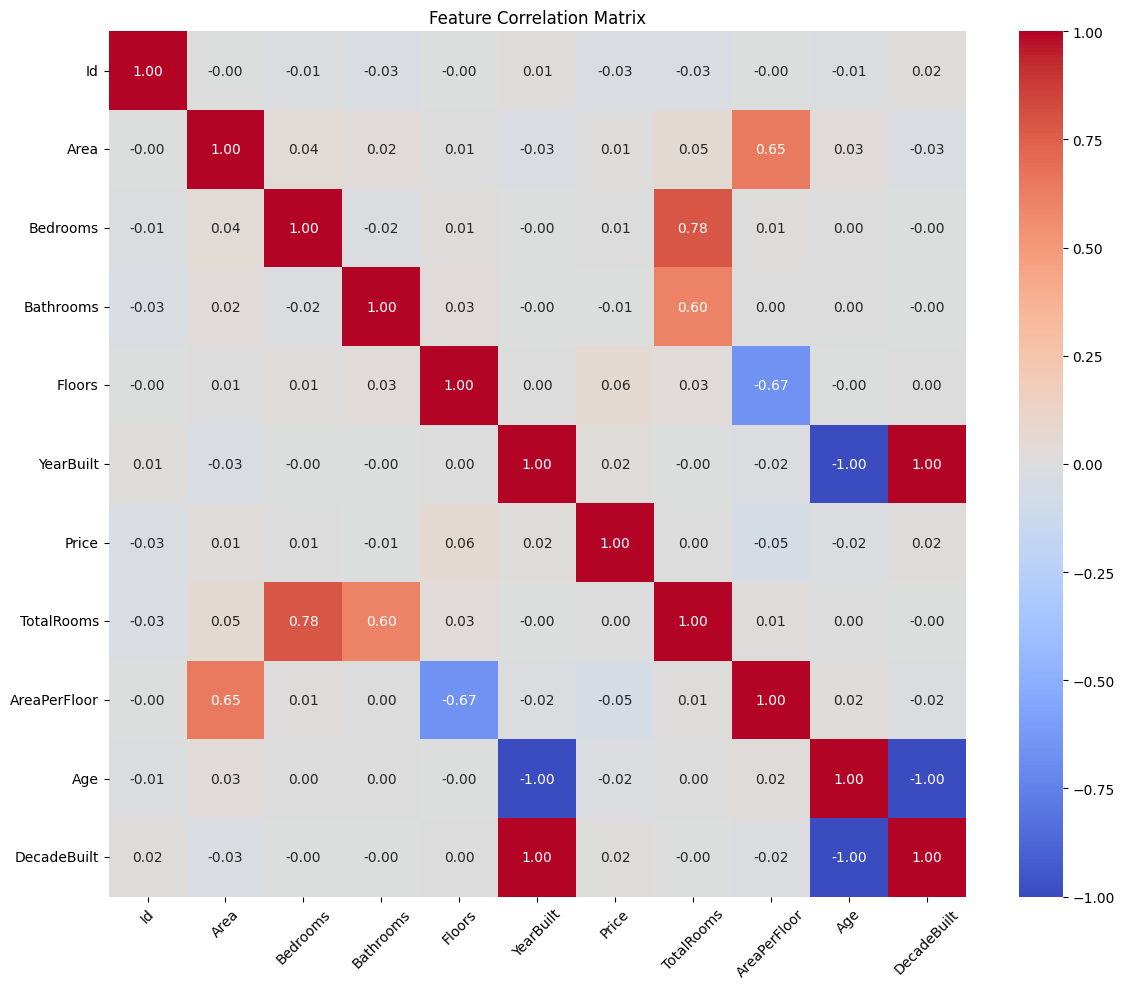


Highly correlated feature pairs (|correlation| > 0.7):
Bedrooms - TotalRooms: 0.78
YearBuilt - Age: -1.00
YearBuilt - DecadeBuilt: 1.00
Age - DecadeBuilt: -1.00


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np





# Calculate correlation matrix for numerical columns
corr_matrix = d.select_dtypes(include=[np.number]).corr()

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print highly correlated features
threshold = 0.7
high_corr = np.where(np.abs(corr_matrix) > threshold)
high_corr = [(corr_matrix.index[x], corr_matrix.columns[y], corr_matrix.iloc[x,y]) 
             for x, y in zip(*high_corr) if x != y and x < y]

print("\nHighly correlated feature pairs (|correlation| > 0.7):")
for feat1, feat2, corr in high_corr:
    print(f"{feat1} - {feat2}: {corr:.2f}")

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming 'd' is your DataFrame with target variable 'Price'
X = d.drop(columns=['Price', 'Id'])  # Drop target and ID columns
y = d['Price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")


Mean Absolute Error (MAE): 233261.77760521942
Mean Squared Error (MSE): 72553894839.53798
R-squared (R2): 0.011698894379210234


In [11]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming 'd' is your DataFrame with target variable 'Price'
X = d.drop(columns=['Price', 'Id'])  # Drop target and ID columns
y = d['Price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dt_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Decision Tree Regressor Metrics:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")


Decision Tree Regressor Metrics:
Mean Absolute Error (MAE): 314304.14444444445
Mean Squared Error (MSE): 150021402368.21112
R-squared (R2): -1.0435335436532243


In [12]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor Metrics:")
print(f"Mean Absolute Error (MAE): {mae_rf}")
print(f"Mean Squared Error (MSE): {mse_rf}")
print(f"R-squared (R2): {r2_rf}")


Random Forest Regressor Metrics:
Mean Absolute Error (MAE): 246482.1206388889
Mean Squared Error (MSE): 81192626909.9176
R-squared (R2): -0.10597457408447575


In [13]:
from xgboost import XGBRegressor

# Initialize and train the XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Regressor Metrics:")
print(f"Mean Absolute Error (MAE): {mae_xgb}")
print(f"Mean Squared Error (MSE): {mse_xgb}")
print(f"R-squared (R2): {r2_xgb}")


XGBoost Regressor Metrics:
Mean Absolute Error (MAE): 246414.890625
Mean Squared Error (MSE): 81828339712.0
R-squared (R2): -0.11463403701782227
